In [1]:
import os
import subprocess
import sys

print("Setting up project environments...")
os.makedirs("./envs", exist_ok=True)
os.makedirs("evaluation_outputs", exist_ok=True)

base_pkgs = [
    "python=3.10",
    "pytorch",
    "torchvision",
    "torchaudio",
    "transformers",
    "pandas",
    "numpy",
    "tqdm",
    "cd-hit",
    "hmmer",
]
conda_args = ["-c", "pytorch", "-c", "conda-forge", "-c", "bioconda", "-y", "-q"]

def run_silent_cmd(cmd, description):
    """Runs command. If it fails, prints error output and stops."""
    try:
        subprocess.run(cmd, check=True, text=True)
    except subprocess.CalledProcessError as e:
        print(f"\nERROR: Failed while {description}")
        sys.exit(1)

def setup_conda_env(env_name, extra_pkgs=None):
    env_path = os.path.abspath(f"./envs/{env_name}")
    python_exec = os.path.join(env_path, "bin", "python")
    pip_exec = os.path.join(env_path, "bin", "pip")

    if not os.path.exists(python_exec):
        print(f"Creating {env_name} environment (this may take a while)...")
        pkgs = base_pkgs + (extra_pkgs if extra_pkgs else [])
        
        conda_cmd = ["conda", "create", "--prefix", env_path] + pkgs + conda_args
        run_silent_cmd(conda_cmd, f"creating Conda environment {env_name}")
        
        pip_cmd = [pip_exec, "install", "-qqq", "abnumber"]
        run_silent_cmd(pip_cmd, f"installing abnumber in {env_name}")
    else:
        print(f"{env_name} environment already exists.")
    return env_path, python_exec, pip_exec

# 0. Main Project Environment
print("Setting up Main Project environment...")
env_main, main_python, main_pip = setup_conda_env("main_env")

# 1. ESM-2
print("Setting up ESM-2 environment...")
env_esm, esm_python, _ = setup_conda_env("plm_esm")

# 2. ProtT5
print("Setting up ProtT5 environment...")
env_prott5, prott5_python, _ = setup_conda_env(
    "plm_prott5", ["sentencepiece", "protobuf"]
)

# 3. Ankh
print("Setting up Ankh environment...")
env_ankh, ankh_python, ankh_pip = setup_conda_env(
    "plm_ankh", ["sentencepiece", "protobuf"]
)
print("Installing 'ankh' package via pip in plm_ankh...")
run_silent_cmd([ankh_pip, "install", "-qqq", "ankh"], "installing ankh via pip")

print("Ensuring PyTorch >= 2.6 across model environments...")
for env_name in ["plm_esm", "plm_prott5", "plm_ankh"]:
    print(f"Upgrading PyTorch in {env_name}...")
    pip_path = os.path.abspath(f"./envs/{env_name}/bin/pip")
    upgrade_cmd = [
        pip_path,
        "install",
        "-qqq",
        "--upgrade",
        "torch",
        "torchvision",
        "torchaudio",
    ]
    run_silent_cmd(upgrade_cmd, f"upgrading PyTorch in {env_name}")

print(
    "Installing main project dependencies (gdown, PyDrive2, Spark,"
    " Findspark, etc.) into main_env..."
)
main_pip_cmd = [
    main_pip,
    "install",
    "-qqq",
    "gdown",
    "tabulate",
    "datasets",
    "scikit-learn",
    "abnumber",
    "findspark",
    "pyspark<4.0",
    "delta-spark<4.0",
    "PyDrive2",
]
run_silent_cmd(main_pip_cmd, "installing main dependencies")

print("\nReady! All environments created under ./envs/:")
print(f"  - Main Python Executable: {main_python}")
print(f"  - ESM Python Executable:  {esm_python}")
print(f"  - ProtT5 Python Executable: {prott5_python}")
print(f"  - Ankh Python Executable:   {ankh_python}")

Setting up project environments...
Setting up Main Project environment...
main_env environment already exists.
Setting up ESM-2 environment...
plm_esm environment already exists.
Setting up ProtT5 environment...
plm_prott5 environment already exists.
Setting up Ankh environment...
plm_ankh environment already exists.
Installing 'ankh' package via pip in plm_ankh...
Ensuring PyTorch >= 2.6 across model environments...
Upgrading PyTorch in plm_esm...
Upgrading PyTorch in plm_prott5...
Upgrading PyTorch in plm_ankh...
Installing main project dependencies (gdown, PyDrive2, Spark, Findspark, etc.) into main_env...

Ready! All environments created under ./envs/:
  - Main Python Executable: /mnt/natanon/EvalTests/envs/main_env/bin/python
  - ESM Python Executable:  /mnt/natanon/EvalTests/envs/plm_esm/bin/python
  - ProtT5 Python Executable: /mnt/natanon/EvalTests/envs/plm_prott5/bin/python
  - Ankh Python Executable:   /mnt/natanon/EvalTests/envs/plm_ankh/bin/python


# 1.2 Prepare dataset

In [2]:
import os
import subprocess
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

output_dir = "evaluation_outputs"
os.makedirs(output_dir, exist_ok=True)

DATASET_SIZE = 5000 # Set to an integer (e.g., 5000) if you wish to subsample for rapid local testing

def parse_asd_affinity(val):
    """
    Safely parses ASD affinity data fields which can be numerical floats, 
    booleans, comparison strings (<, >, ~), ranges, or fuzzy text flags.
    """
    if pd.isna(val):
        return np.nan
    
    # Handle direct python/numpy booleans
    if isinstance(val, (bool, np.bool_)):
        return 1.0 if val else 0.0
        
    val_str = str(val).strip().lower()
    
    # Handle text categorical flags often found in literature/patent subsets
    true_flags = ['true', 'yes', 'positive', 'binder', '1', '1.0']
    false_flags = ['false', 'no', 'negative', 'non-binder', '0', '0.0']
    
    if val_str in true_flags:
        return 1.0
    if val_str in false_flags:
        return 0.0
        
    # Strip common measurement prefixes
    for prefix in ['<', '>', '=', '~', 'approx', 'ic50', 'kd']:
        if val_str.startswith(prefix):
            val_str = val_str[len(prefix):].strip()
            
    # Handle numeric ranges (e.g., "10-50") by taking the midpoint
    if '-' in val_str and not val_str.startswith('-'):
        try:
            parts = val_str.split('-')
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2.0
        except ValueError:
            pass
            
    try:
        return float(val_str)
    except ValueError:
        return np.nan

# ==========================================
# 1. Securely Load and Parse ASD Dataset Files
# ==========================================
asd_data_path = "./asd_data"
if not os.path.exists(asd_data_path):
    raise FileNotFoundError(f"Local path '{asd_data_path}' not found. Please place your unpacked ASD database files there.")

print("Scanning and parsing data files from local ASD repository...")
data_frames = []

for root, dirs, files in os.walk(asd_data_path):
    for file in files:
        if file.startswith('.') or file.endswith('.crc'):
            continue  
        
        file_path = os.path.join(root, file)
        
        if file.endswith('.parquet') or 'part-' in file:
            try:
                df_part = pd.read_parquet(file_path)
                data_frames.append(df_part)
            except Exception:
                pass
        
        elif file.endswith('.csv') or file.endswith('.tsv'):
            try:
                sep = '\t' if file.endswith('.tsv') else ','
                df_part = pd.read_csv(file_path, sep=sep)
                if len(df_part.columns) > 1:
                    data_frames.append(df_part)
            except Exception:
                pass

if not data_frames:
    raise RuntimeError(f"No valid data files found inside '{asd_data_path}'.")

df = pd.concat(data_frames, ignore_index=True)
print("Available raw columns found in ASD dataset:", df.columns.tolist())

# Map columns securely based on the official ASD standardized schema specification
h_col = next((c for c in ['heavy_sequence', 'heavy_chain_seq'] if c in df.columns), df.columns[0])
l_col = next((c for c in ['light_sequence', 'light_chain_seq'] if c in df.columns), df.columns[1] if len(df.columns) > 1 else h_col)
a_col = next((c for c in ['antigen_sequence', 'antigen_seq', 'target_seq'] if c in df.columns), df.columns[2] if len(df.columns) > 2 else h_col)
s_col = next((c for c in ['affinity', 'binding_score', 'ic_50'] if c in df.columns), df.columns[-1])

# Parse core amino-acid chain sequences safely
df['heavy_sequence'] = df[h_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})
df['light_sequence'] = df[l_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})
df['antigen_sequence'] = df[a_col].astype(str).str.strip().replace({'nan': '', 'None': '', 'True': '', 'False': ''})

# Apply robust fuzzy/boolean affinity parser to handle mixed datatype sources
df['affinity_parsed'] = df[s_col].apply(parse_asd_affinity)

# Extract standard ASD metadata properties safely if present
df['confidence'] = df['confidence'] if 'confidence' in df.columns else 'high'
df['dataset_source'] = df['dataset'] if 'dataset' in df.columns else 'asd_local'
df['affinity_type'] = df['affinity_type'] if 'affinity_type' in df.columns else 'unknown'

# Drop rows missing critical sequences or unparseable affinities
df.replace("", np.nan, inplace=True)
df = df.dropna(subset=['heavy_sequence', 'light_sequence', 'antigen_sequence', 'affinity_parsed']).reset_index(drop=True)

# Filter out malformed or short chain sequences
df = df[
    (df['heavy_sequence'].str.len() > 20) & 
    (df['light_sequence'].str.len() > 20) &
    (df['antigen_sequence'].str.len() > 5)
].reset_index(drop=True)

if DATASET_SIZE is not None and len(df) > DATASET_SIZE:
    df = df.sample(n=DATASET_SIZE, random_state=42).reset_index(drop=True)
    print(f"ASD dataset truncated to {DATASET_SIZE} rows.")

# ==========================================
# Context-Aware Affinity-to-Label Conversion
# ==========================================
def get_binarized_label(group):
    """
    Safely binarizes affinity values based on their source measurement type 
    to handle inverted scales (e.g., Kd/IC50 where lower is better vs scores where higher is better).
    """
    if set(group['affinity_parsed'].unique()).issubset({0.0, 1.0}):
        return group['affinity_parsed'].astype(int)
        
    aff_type = str(group['affinity_type'].iloc[0]).lower() if 'affinity_type' in group.columns else 'unknown'
    lower_is_better = any(term in aff_type for term in ['kd', 'ki', 'ic50', 'ec50', 'dissociation', 'delta_g'])
    
    if lower_is_better:
        thresh = group['affinity_parsed'].quantile(0.10)
        return (group['affinity_parsed'] <= thresh).astype(int)
    else:
        thresh = group['affinity_parsed'].quantile(0.90)
        return (group['affinity_parsed'] >= thresh).astype(int)

if 'affinity_type' in df.columns:
    df['label'] = df.groupby('affinity_type', group_keys=False).apply(get_binarized_label, include_groups=False)
else:
    unique_vals = df['affinity_parsed'].unique()
    if set(unique_vals).issubset({0.0, 1.0}):
        df['label'] = df['affinity_parsed'].astype(int)
    else:
        threshold = df['affinity_parsed'].quantile(0.90)
        df['label'] = (df['affinity_parsed'] >= threshold).astype(int)

# ==========================================
# 2. Sequence Clustering via CD-HIT
# ==========================================
df['concat_sequence'] = df['heavy_sequence'] + "GGGG" + df['light_sequence'] + "GGGG" + df['antigen_sequence']

fasta_path = os.path.join(output_dir, "asd_sequences.fasta")
with open(fasta_path, "w") as f:
    for i, seq in enumerate(df['concat_sequence']):
        f.write(f">seq_{i}\n{seq}\n")

cdhit_out = os.path.join(output_dir, "asd_clustered")
subprocess.run([
    os.path.abspath("./envs/plm_esm/bin/cd-hit"),
    "-i", fasta_path, "-o", cdhit_out, 
    "-c", "0.8", "-n", "5", "-M", "0"
], check=True, stdout=subprocess.DEVNULL)

cluster_dict = {}
clstr_file = cdhit_out + ".clstr"
if os.path.exists(clstr_file):
    with open(clstr_file, "r") as f:
        current_cluster = None
        for line in f:
            if line.startswith(">Cluster"):
                current_cluster = int(line.split()[1])
            else:
                try:
                    seq_idx = int(line.split(">")[1].split("...")[0].split("_")[1])
                    cluster_dict[seq_idx] = current_cluster
                except Exception:
                    pass

df['cluster_id'] = df.index.map(cluster_dict)

# Safeguard against unclustered NaN assignments to prevent GroupShuffleSplit errors
df['cluster_id'] = df['cluster_id'].fillna(-1).astype(int)
unclustered_mask = df['cluster_id'] == -1
if unclustered_mask.sum() > 0:
    df.loc[unclustered_mask, 'cluster_id'] = range(-999, -999 - unclustered_mask.sum(), -1)

# ==========================================
# 3. Group-Aware Splitting & Export
# ==========================================
found_valid_split = False
for seed in range(42, 100):
    gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=seed)
    train_idx, test_idx = next(gss.split(df, groups=df['cluster_id']))
    
    y_tr_temp = df['label'].iloc[train_idx]
    y_te_temp = df['label'].iloc[test_idx]
    
    if len(y_tr_temp.unique()) > 1 and len(y_te_temp.unique()) > 1:
        found_valid_split = True
        break

if not found_valid_split:
    raise RuntimeError("Could not find a valid group split. Try adjusting dataset size or threshold parameters.")

df['split'] = 'train'
df.iloc[test_idx, df.columns.get_loc('split')] = 'test'

final_df = df[['heavy_sequence', 'light_sequence', 'antigen_sequence', 'affinity_parsed', 'label', 'split', 'cluster_id']].reset_index(drop=True)
final_df.to_csv(os.path.join(output_dir, "abag_full_dataset.csv"), index=False)

print(f"ASD dataset processing complete successfully.")
print(f" - Train set size: {len(final_df[final_df['split']=='train'])}")
print(f" - Test set size:  {len(final_df[final_df['split']=='test'])}")

Scanning and parsing data files from local ASD repository...
Available raw columns found in ASD dataset: ['dataset', 'heavy_sequence', 'light_sequence', 'scfv', 'affinity_type', 'affinity', 'antigen_sequence', 'confidence', 'nanobody', 'metadata', 'processed_measurement']
ASD dataset truncated to 5000 rows.
ASD dataset processing complete successfully.
 - Train set size: 4677
 - Test set size:  323


In [3]:
print(final_df)

                                         heavy_sequence  \
0     QVQLKESGPDLVAPSQSLSITCTVSGFSLTNYGVHWVRQFPGKGLE...   
1     QVQLVQSGAEVKKPGSSVKVSCKASGGTFNNYAISWVRQAPGQGLE...   
2     EVQLVETGGGLVQPGGSLRLSCAASGFQLNEYGISWVRQAPGKGPE...   
3     QVQLVQSGAEVKKPGSSVKVSCKASGGTSSNYAISWVRQAPGQGLE...   
4     QVQLVQSGAEVKKPGSSVKVSCKASGGTFNSYAISWVRQAPGQGLE...   
...                                                 ...   
4995  QVQLVQSGAEVKKPGSSVKVSCKASGGTSNNYAISWVRQAPGQGLE...   
4996  EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLE...   
4997  EVQLVETGGGLVQPGGSLRLSCAASGFDINEYGISWVRQAPGKGPE...   
4998  QVQLVQSGAEVKKPGSSVKVSCKASGGTFNNYAISWVRQAPGQGLE...   
4999  QVQLVQSGAEVKKPGSSVKVSCKASGGTSSSYAISWVRQAPGQGLE...   

                                         light_sequence  \
0     ENVLTQSPAIMSASPGEKVTMTCGASSSVSSSFLHWYQQKSGASPK...   
1     QSALTQPPAVSGTPGQRVTISCSGSDSNIGRRSVNWYQQFPGTAPK...   
2     DVVMTQSPESLAVSLGERATISCKSSQSVLYESRNKNSVAWYQQKA...   
3     QSALTQPPAVSGTPGQRVTISCSGSDSNIGRRSVNWYQQFPGTAPK...

## Step 1.2.2: import and test with the ASD dataset

# Step 2: Run the models
## Step 2.1: ESM-2

In [4]:
import os
import subprocess

esm_script = """import os, torch, pickle, gc
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, EsmModel
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: 
        return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
antigen_seqs = df["antigen_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model = EsmModel.from_pretrained("facebook/esm2_t6_8M_UR50D").to(device)
model.eval()

embeddings = []
TOKEN_OFFSET = 1  

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    if cdr_bounds:
        cdrs = torch.cat([
            last_hidden[cdr_bounds['CDR1'][0] + TOKEN_OFFSET : cdr_bounds['CDR1'][1] + TOKEN_OFFSET],
            last_hidden[cdr_bounds['CDR2'][0] + TOKEN_OFFSET : cdr_bounds['CDR2'][1] + TOKEN_OFFSET],
            last_hidden[cdr_bounds['CDR3'][0] + TOKEN_OFFSET : cdr_bounds['CDR3'][1] + TOKEN_OFFSET]
        ], dim=0)
        return cdrs.mean(dim=0).numpy()
    else:
        return last_hidden[TOKEN_OFFSET : min(len(seq), 510) + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), 32), desc="ESM-2 Complex Extraction"):
        batch_h = heavy_seqs[i:i+32]
        batch_l = light_seqs[i:i+32]
        batch_ag = antigen_seqs[i:i+32]
        
        inputs_h = tokenizer(batch_h, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_h = model(**inputs_h)
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu()
        del inputs_h, outputs_h
        
        inputs_l = tokenizer(batch_l, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_l = model(**inputs_l)
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu()
        del inputs_l, outputs_l
        
        # Antigen Pass
        inputs_ag = tokenizer(batch_ag, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_ag = model(**inputs_ag)
        last_hidden_ag = outputs_ag.last_hidden_state.detach().cpu()
        del inputs_ag, outputs_ag
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        for j in range(len(batch_h)):
            emb_h = extract_chain_embedding(batch_h[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l[j], last_hidden_l[j])
            
            # Antigen (no CDRs, simple mean over sequence length)
            seq_len_ag = min(len(batch_ag[j]), last_hidden_ag[j].size(0) - TOKEN_OFFSET * 2)
            emb_ag = last_hidden_ag[j][TOKEN_OFFSET : seq_len_ag + TOKEN_OFFSET].mean(dim=0).numpy()
            
            # Concatenates (320,) x3 to (960,)
            embeddings.append(np.concatenate([emb_h, emb_l, emb_ag]))

with open("evaluation_outputs/esm2_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)
"""

with open("run_esm.py", "w") as f: f.write(esm_script)
subprocess.run([os.path.abspath("./envs/plm_esm/bin/python"), "run_esm.py"], check=True)
print("ESM-2 extraction complete.")

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 6640.16it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
ESM-2 Complex Extraction: 100%|██████████| 157/157 [00:36<00:00,  4.33it/s]


ESM-2 extraction complete.


## Step 2.1.1 ESM2 3B

In [5]:
import os
import subprocess

esm3b_script = """import os, torch, pickle, gc
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, EsmModel
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
antigen_seqs = df["antigen_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "facebook/esm2_t36_3B_UR50D"

print(f"Loading {model_name} in float32...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = EsmModel.from_pretrained(model_name, torch_dtype=torch.float32).to(device)
model.eval()

embeddings = []
TOKEN_OFFSET = 1  
batch_size = 2  

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    max_len = last_hidden.size(0) 
    
    if cdr_bounds:
        c1_start = min(cdr_bounds['CDR1'][0] + TOKEN_OFFSET, max_len)
        c1_end   = min(cdr_bounds['CDR1'][1] + TOKEN_OFFSET, max_len)
        c2_start = min(cdr_bounds['CDR2'][0] + TOKEN_OFFSET, max_len)
        c2_end   = min(cdr_bounds['CDR2'][1] + TOKEN_OFFSET, max_len)
        c3_start = min(cdr_bounds['CDR3'][0] + TOKEN_OFFSET, max_len)
        c3_end   = min(cdr_bounds['CDR3'][1] + TOKEN_OFFSET, max_len)
        
        cdrs = torch.cat([
            last_hidden[c1_start:c1_end],
            last_hidden[c2_start:c2_end],
            last_hidden[c3_start:c3_end]
        ], dim=0)
        
        if cdrs.size(0) > 0:
            return cdrs.mean(dim=0).numpy()
            
    seq_len = min(len(seq), max_len - TOKEN_OFFSET)
    return last_hidden[TOKEN_OFFSET : seq_len + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), batch_size), desc="ESM-2 (3B) Complex Extraction"):
        batch_h = heavy_seqs[i:i+batch_size]
        batch_l = light_seqs[i:i+batch_size]
        batch_ag = antigen_seqs[i:i+batch_size]
        
        inputs_h = tokenizer(batch_h, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_h = model(**inputs_h)
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu().float()
        del inputs_h, outputs_h
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_l = tokenizer(batch_l, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_l = model(**inputs_l)
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu().float()
        del inputs_l, outputs_l
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_ag = tokenizer(batch_ag, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_ag = model(**inputs_ag)
        last_hidden_ag = outputs_ag.last_hidden_state.detach().cpu().float()
        del inputs_ag, outputs_ag
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        for j in range(len(batch_h)):
            emb_h = extract_chain_embedding(batch_h[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l[j], last_hidden_l[j])
            
            seq_len_ag = min(len(batch_ag[j]), last_hidden_ag[j].size(0) - TOKEN_OFFSET)
            emb_ag = last_hidden_ag[j][TOKEN_OFFSET : seq_len_ag + TOKEN_OFFSET].mean(dim=0).numpy()
            
            embeddings.append(np.concatenate([emb_h, emb_l, emb_ag]))

with open("evaluation_outputs/esm2_3b_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)

del model, tokenizer, embeddings; gc.collect(); torch.cuda.empty_cache()
"""

with open("run_esm3b.py", "w") as f: f.write(esm3b_script)
subprocess.run([os.path.abspath("./envs/plm_esm/bin/python"), "run_esm3b.py"], check=True)
print("ESM-2 (3B) extraction complete.")

Loading facebook/esm2_t36_3B_UR50D in float32...


Loading weights: 100%|██████████| 582/582 [00:00<00:00, 42856.13it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t36_3B_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
ESM-2 (3B) Complex Extraction: 100%|██████████| 2500/2500 [59:30<00:00,  1.43s/it]


ESM-2 (3B) extraction complete.


## Step 2.2: ProtT5

In [6]:
import os
import subprocess

prott5_script = """import os, torch, pickle, re, gc
import pandas as pd
import numpy as np
from transformers import T5Tokenizer, T5EncoderModel
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
antigen_seqs = df["antigen_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("Rostlab/prot_t5_xl_half_uniref50-enc", do_lower_case=False)
model = T5EncoderModel.from_pretrained("Rostlab/prot_t5_xl_half_uniref50-enc").to(device)
model.eval()
if torch.cuda.is_available(): model.half()

embeddings = []
TOKEN_OFFSET = 0
batch_size = 8  

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    max_len = last_hidden.size(0)
    
    if cdr_bounds:
        c1_start = min(cdr_bounds['CDR1'][0] + TOKEN_OFFSET, max_len)
        c1_end   = min(cdr_bounds['CDR1'][1] + TOKEN_OFFSET, max_len)
        c2_start = min(cdr_bounds['CDR2'][0] + TOKEN_OFFSET, max_len)
        c2_end   = min(cdr_bounds['CDR2'][1] + TOKEN_OFFSET, max_len)
        c3_start = min(cdr_bounds['CDR3'][0] + TOKEN_OFFSET, max_len)
        c3_end   = min(cdr_bounds['CDR3'][1] + TOKEN_OFFSET, max_len)
        
        cdrs = torch.cat([
            last_hidden[c1_start:c1_end],
            last_hidden[c2_start:c2_end],
            last_hidden[c3_start:c3_end]
        ], dim=0)
        
        if cdrs.size(0) > 0:
            return cdrs.mean(dim=0).numpy()
            
    seq_len = min(len(seq), max_len - TOKEN_OFFSET)
    return last_hidden[TOKEN_OFFSET : seq_len + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), batch_size), desc="ProtT5 Complex Extraction"):
        batch_h_raw = heavy_seqs[i:i+batch_size]
        batch_l_raw = light_seqs[i:i+batch_size]
        batch_ag_raw = antigen_seqs[i:i+batch_size]
        
        batch_h_spaced = [" ".join(list(re.sub(r"[UZOB]", "X", seq))) for seq in batch_h_raw]
        batch_l_spaced = [" ".join(list(re.sub(r"[UZOB]", "X", seq))) for seq in batch_l_raw]
        batch_ag_spaced = [" ".join(list(re.sub(r"[UZOB]", "X", seq))) for seq in batch_ag_raw]
        
        inputs_h = tokenizer(batch_h_spaced, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_h = model(**inputs_h)
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu().float()
        del inputs_h, outputs_h
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_l = tokenizer(batch_l_spaced, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_l = model(**inputs_l)
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu().float()
        del inputs_l, outputs_l
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_ag = tokenizer(batch_ag_spaced, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        outputs_ag = model(**inputs_ag)
        last_hidden_ag = outputs_ag.last_hidden_state.detach().cpu().float()
        del inputs_ag, outputs_ag
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        for j in range(len(batch_h_raw)):
            emb_h = extract_chain_embedding(batch_h_raw[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l_raw[j], last_hidden_l[j])
            
            seq_len_ag = min(len(batch_ag_raw[j]), last_hidden_ag[j].size(0) - TOKEN_OFFSET)
            emb_ag = last_hidden_ag[j][TOKEN_OFFSET : seq_len_ag + TOKEN_OFFSET].mean(dim=0).numpy()
            
            embeddings.append(np.concatenate([emb_h, emb_l, emb_ag]))

with open("evaluation_outputs/prott5_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)

del model, tokenizer, embeddings; gc.collect(); torch.cuda.empty_cache()
"""

with open("run_prott5.py", "w") as f: f.write(prott5_script)
subprocess.run([os.path.abspath("./envs/plm_prott5/bin/python"), "run_prott5.py"], check=True)
print("ProtT5 extraction complete.")

ProtT5 Complex Extraction: 100%|██████████| 625/625 [08:01<00:00,  1.30it/s]


ProtT5 extraction complete.


## PLM Ankh

In [10]:
import os
import subprocess

ankh_fixed_script = """import os
# Prevent CUDA memory fragmentation from variable-length sequence padding
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch, pickle, gc
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm
from abnumber import Chain

def get_cdr_indices(sequence, scheme='imgt'):
    try:
        chain = Chain(sequence, scheme=scheme)
        c1, c2, c3 = sequence.find(chain.cdr1_seq), sequence.find(chain.cdr2_seq), sequence.find(chain.cdr3_seq)
        if -1 in (c1, c2, c3): return None
        return {'CDR1': (c1, c1 + len(chain.cdr1_seq)), 
                'CDR2': (c2, c2 + len(chain.cdr2_seq)), 
                'CDR3': (c3, c3 + len(chain.cdr3_seq))}
    except Exception: return None

df = pd.read_csv("evaluation_outputs/abag_full_dataset.csv").fillna("")
heavy_seqs = df["heavy_sequence"].astype(str).tolist()
light_seqs = df["light_sequence"].astype(str).tolist()
antigen_seqs = df["antigen_sequence"].astype(str).tolist()
labels = df["label"].tolist()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("ElnaggarLab/ankh-base")
model = AutoModelForSeq2SeqLM.from_pretrained("ElnaggarLab/ankh-base").to(device)
model.eval()

embeddings = []
TOKEN_OFFSET = 0 
batch_size = 1 # Reduced to 1 to prevent OOM padding spikes on antigens

def extract_chain_embedding(seq, last_hidden):
    cdr_bounds = get_cdr_indices(seq)
    max_len = last_hidden.size(0)
    
    if cdr_bounds:
        c1_start = min(cdr_bounds['CDR1'][0] + TOKEN_OFFSET, max_len)
        c1_end   = min(cdr_bounds['CDR1'][1] + TOKEN_OFFSET, max_len)
        c2_start = min(cdr_bounds['CDR2'][0] + TOKEN_OFFSET, max_len)
        c2_end   = min(cdr_bounds['CDR2'][1] + TOKEN_OFFSET, max_len)
        c3_start = min(cdr_bounds['CDR3'][0] + TOKEN_OFFSET, max_len)
        c3_end   = min(cdr_bounds['CDR3'][1] + TOKEN_OFFSET, max_len)
        
        cdrs = torch.cat([
            last_hidden[c1_start:c1_end],
            last_hidden[c2_start:c2_end],
            last_hidden[c3_start:c3_end]
        ], dim=0)
        
        if cdrs.size(0) > 0:
            return cdrs.mean(dim=0).numpy()
            
    seq_len = min(len(seq), max_len - TOKEN_OFFSET)
    return last_hidden[TOKEN_OFFSET : seq_len + TOKEN_OFFSET].mean(dim=0).numpy()

with torch.no_grad():
    for i in tqdm(range(0, len(heavy_seqs), batch_size), desc="Ankh Complex Extraction"):
        batch_h = heavy_seqs[i:i+batch_size]
        batch_l = light_seqs[i:i+batch_size]
        batch_ag = antigen_seqs[i:i+batch_size]
        
        inputs_h = tokenizer([list(seq) for seq in batch_h], add_special_tokens=True, padding=True, is_split_into_words=True, return_tensors="pt").to(device)
        outputs_h = model.get_encoder()(input_ids=inputs_h['input_ids'], attention_mask=inputs_h['attention_mask'])
        last_hidden_h = outputs_h.last_hidden_state.detach().cpu()
        del inputs_h, outputs_h
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_l = tokenizer([list(seq) for seq in batch_l], add_special_tokens=True, padding=True, is_split_into_words=True, return_tensors="pt").to(device)
        outputs_l = model.get_encoder()(input_ids=inputs_l['input_ids'], attention_mask=inputs_l['attention_mask'])
        last_hidden_l = outputs_l.last_hidden_state.detach().cpu()
        del inputs_l, outputs_l
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        inputs_ag = tokenizer([list(seq) for seq in batch_ag], add_special_tokens=True, padding=True, is_split_into_words=True, return_tensors="pt").to(device)
        outputs_ag = model.get_encoder()(input_ids=inputs_ag['input_ids'], attention_mask=inputs_ag['attention_mask'])
        last_hidden_ag = outputs_ag.last_hidden_state.detach().cpu()
        del inputs_ag, outputs_ag
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        
        for j in range(len(batch_h)):
            emb_h = extract_chain_embedding(batch_h[j], last_hidden_h[j])
            emb_l = extract_chain_embedding(batch_l[j], last_hidden_l[j])
            
            seq_len_ag = min(len(batch_ag[j]), last_hidden_ag[j].size(0) - TOKEN_OFFSET)
            emb_ag = last_hidden_ag[j][TOKEN_OFFSET : seq_len_ag + TOKEN_OFFSET].mean(dim=0).numpy()
            
            embeddings.append(np.concatenate([emb_h, emb_l, emb_ag]))

with open("evaluation_outputs/ankh_abag_full_results.pkl", "wb") as f:
    pickle.dump({"embeddings": embeddings, "labels": labels}, f)

del model, tokenizer, embeddings; gc.collect(); torch.cuda.empty_cache()
"""

with open("run_ankh_fixed.py", "w") as f: 
    f.write(ankh_fixed_script)
subprocess.run([os.path.abspath("./envs/plm_ankh/bin/python"), "run_ankh_fixed.py"], check=True)
print("Ankh extraction complete.")

Ankh Complex Extraction: 100%|██████████| 5000/5000 [13:49<00:00,  6.03it/s]  


Ankh extraction complete.


# Step 3: Evaluate the model results against known answers

📊 Metadata Loaded | Splits found: ['train', 'test']
⚖️ Balancing Configuration -> Train 50/50: True | Test 50/50: True

[*] ESM-2 (8M) Loaded | Vector Dim: 960 | Total Available Embeddings: 5000
    ⚙️ Train Subset: 2086 samples (1043 Binders / 1043 Non-Binders)
    -> Fitting LogReg (Linear)...
    -> Fitting Random Forest (Tree)...
    -> Fitting MLP (Neural Net)...

[*] ESM-2 (3B) Loaded | Vector Dim: 7680 | Total Available Embeddings: 5000
    ⚙️ Train Subset: 2086 samples (1043 Binders / 1043 Non-Binders)
    -> Fitting LogReg (Linear)...
    -> Fitting Random Forest (Tree)...
    -> Fitting MLP (Neural Net)...

[*] ProtT5-XL Loaded | Vector Dim: 3072 | Total Available Embeddings: 5000
    ⚙️ Train Subset: 2086 samples (1043 Binders / 1043 Non-Binders)
    -> Fitting LogReg (Linear)...
    -> Fitting Random Forest (Tree)...
    -> Fitting MLP (Neural Net)...

[*] Ankh-Base Loaded | Vector Dim: 2304 | Total Available Embeddings: 5000
    ⚙️ Train Subset: 2086 samples (1043 Binders 

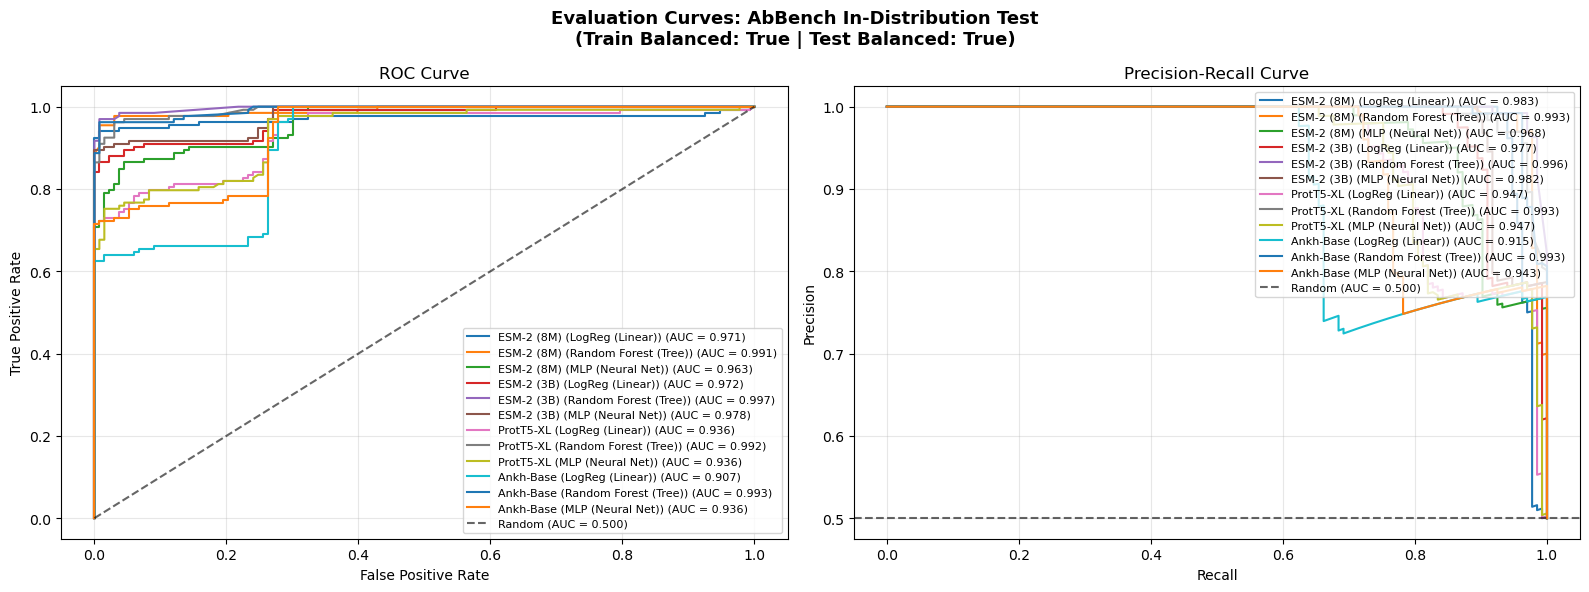

In [11]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# ==============================================================================
# ⚙️ FLEXIBLE SPLIT & BALANCING CONFIGURATION
# ==============================================================================
SPLIT_COLUMN = "split"

# 1. Training Set Selection
TRAIN_SPLITS = ["train"]  # e.g., ["train"] or ["train", "test"]
BALANCE_TRAIN = True      # True = Downsample majority class to 50% binders / 50% non-binders

# 2. Test Set Selection
TEST_SPLITS_CONFIG = {
    "AbBench In-Distribution Test": ["test"],
    "ASD Out-of-Distribution Test": ["test_asd"]
}
BALANCE_TEST = True       # True = Downsample test set(s) to 50% binders / 50% non-binders

# 3. Reproducibility
RANDOM_SEED = 42
# ==============================================================================

output_dir = "evaluation_outputs"
meta_path = os.path.join(output_dir, "abag_full_dataset.csv")

if not os.path.exists(meta_path):
    raise FileNotFoundError(f"Metadata file not found at {meta_path}. Ensure data prep cell has executed.")

df_meta = pd.read_csv(meta_path)

if SPLIT_COLUMN not in df_meta.columns:
    raise KeyError(f"Column '{SPLIT_COLUMN}' not found in metadata. Available columns: {list(df_meta.columns)}")

print(f"📊 Metadata Loaded | Splits found: {df_meta[SPLIT_COLUMN].unique().tolist()}")
print(f"⚖️ Balancing Configuration -> Train 50/50: {BALANCE_TRAIN} | Test 50/50: {BALANCE_TEST}")

# Downstream Classifiers
classifiers = {
    "LogReg (Linear)": LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED
    ),
    "Random Forest (Tree)": RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=RANDOM_SEED
    ),
    "MLP (Neural Net)": MLPClassifier(
        hidden_layer_sizes=(256, 64), max_iter=500, early_stopping=True, random_state=RANDOM_SEED
    )
}

def get_balanced_mask(df, split_values, balance_enabled=True, seed=42):
    """
    Generates a boolean numpy mask ensuring 50/50 positive/negative balance
    for a selected split or set of splits.
    """
    split_mask = df[SPLIT_COLUMN].isin(split_values).values
    indices = np.where(split_mask)[0]
    
    if not balance_enabled or len(indices) == 0:
        return split_mask

    labels = df.loc[split_mask, 'label'].values
    pos_idx = indices[labels == 1]
    neg_idx = indices[labels == 0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return split_mask  # Cannot balance if one class is missing

    min_count = min(len(pos_idx), len(neg_idx))
    rng = np.random.default_rng(seed)
    
    balanced_pos = rng.choice(pos_idx, size=min_count, replace=False)
    balanced_neg = rng.choice(neg_idx, size=min_count, replace=False)
    
    balanced_indices = np.concatenate([balanced_pos, balanced_neg])
    
    final_mask = np.zeros(len(df), dtype=bool)
    final_mask[balanced_indices] = True
    return final_mask

# Create globally consistent masks so ALL models evaluate on identical samples
train_mask = get_balanced_mask(df_meta, TRAIN_SPLITS, balance_enabled=BALANCE_TRAIN, seed=RANDOM_SEED)

test_masks = {
    test_name: get_balanced_mask(df_meta, target_splits, balance_enabled=BALANCE_TEST, seed=RANDOM_SEED)
    for test_name, target_splits in TEST_SPLITS_CONFIG.items()
}

def evaluate_embeddings(file_path, plm_name):
    if not os.path.exists(file_path): 
        print(f"Skipping {plm_name}: File not found at {file_path}")
        return {}, {}
        
    with open(file_path, "rb") as f: 
        data = pickle.load(f)
        
    X = np.array(data["embeddings"])
    y = np.array(data["labels"])
    
    dim = X.shape[1] if len(X.shape) > 1 else 0
    print(f"\n[*] {plm_name} Loaded | Vector Dim: {dim} | Total Available Embeddings: {len(X)}")
    
    if np.isnan(X).any():
        print(f"⚠️ Warning: {plm_name} embeddings contain NaNs. Replacing with zeros.")
        X = np.nan_to_num(X)

    # Slice predefined masks to match exact available embedding length
    n_samples = len(X)
    curr_train_mask = train_mask[:n_samples]

    X_train, y_train = X[curr_train_mask], y[curr_train_mask]
    
    n_pos_train, n_neg_train = np.sum(y_train == 1), np.sum(y_train == 0)
    print(f"    ⚙️ Train Subset: {len(X_train)} samples ({n_pos_train} Binders / {n_neg_train} Non-Binders)")

    if len(X_train) == 0 or len(np.unique(y_train)) < 2:
        print(f"⚠️ Skipping {plm_name}: Training set invalid or contains only one class.")
        return {}, {}
        
    model_results = {test_name: [] for test_name in TEST_SPLITS_CONFIG}
    model_curves = {test_name: [] for test_name in TEST_SPLITS_CONFIG}

    # Evaluate Each Classifier
    for clf_name, clf in classifiers.items():
        print(f"    -> Fitting {clf_name}...")
        
        # Early stopping safety check for MLP
        if isinstance(clf, MLPClassifier):
            _, class_counts = np.unique(y_train, return_counts=True)
            if np.min(class_counts) < 2:
                clf.set_params(early_stopping=False)
            else:
                clf.set_params(early_stopping=True)

        clf.fit(X_train, y_train)
        
        # Process Test Splits
        for test_name in TEST_SPLITS_CONFIG:
            curr_test_mask = test_masks[test_name][:n_samples]
            X_test, y_test = X[curr_test_mask], y[curr_test_mask]

            if len(X_test) == 0 or len(np.unique(y_test)) < 2:
                continue

            y_proba = clf.predict_proba(X_test)[:, 1]
            
            # ROC & PR metrics
            fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            roc_auc = roc_auc_score(y_test, y_proba)
            pr_auc = average_precision_score(y_test, y_proba)
            
            # Optimal decision threshold via Youden's J
            optimal_idx = np.argmax(tpr - fpr)
            optimal_threshold = thresholds_roc[optimal_idx]
            
            y_pred_opt = (y_proba >= optimal_threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
            bal_acc = balanced_accuracy_score(y_test, y_pred_opt)
            
            res_dict = {
                "PLM Encoder": plm_name,
                "Downstream Model": clf_name,
                "Threshold": round(float(optimal_threshold), 4),
                "Balanced Acc": round(float(bal_acc), 4),
                "ROC-AUC": round(float(roc_auc), 4),
                "PR-AUC (Discovery)": round(float(pr_auc), 4),
                "Total Positives": int(tp + fn),
                "Total Negatives": int(tn + fp),
                "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)
            }
            
            curve_dict = {
                "label": f"{plm_name} ({clf_name})",
                "fpr": fpr, "tpr": tpr, "roc_auc": float(roc_auc),
                "prec": prec, "rec": rec, "pr_auc": float(pr_auc)
            }
            
            model_results[test_name].append(res_dict)
            model_curves[test_name].append(curve_dict)

    return model_results, model_curves

# Models to run
models_to_eval = [
    (os.path.join(output_dir, "esm2_abag_full_results.pkl"), "ESM-2 (8M)"),
    (os.path.join(output_dir, "esm2_3b_abag_full_results.pkl"), "ESM-2 (3B)"),
    (os.path.join(output_dir, "prott5_abag_full_results.pkl"), "ProtT5-XL"),
    (os.path.join(output_dir, "ankh_abag_full_results.pkl"), "Ankh-Base")
]

all_results = {test_name: [] for test_name in TEST_SPLITS_CONFIG}
all_curves = {test_name: [] for test_name in TEST_SPLITS_CONFIG}

for path, name in models_to_eval:
    res, cur = evaluate_embeddings(path, name)
    for test_name in TEST_SPLITS_CONFIG:
        all_results[test_name].extend(res.get(test_name, []))
        all_curves[test_name].extend(cur.get(test_name, []))

# ==========================================
# 🏆 Output Leaderboards
# ==========================================
for test_name, target_splits in TEST_SPLITS_CONFIG.items():
    results = all_results[test_name]
    if not results:
        continue

    # Compute exact random baseline PR-AUC for the active test mask
    y_test_active = df_meta.loc[test_masks[test_name], 'label'].values
    random_baseline_pr = float(y_test_active.mean()) if len(y_test_active) > 0 else 0.500

    df_leaderboard = pd.DataFrame(results).sort_values(by="PR-AUC (Discovery)", ascending=False)
    
    print("\n" + "=" * 120)
    print(f"🏆 Leaderboard: {test_name} (Target Splits: {target_splits}) 🏆")
    print(f"⚙️ Train Splits: {TRAIN_SPLITS} (Balanced: {BALANCE_TRAIN}) | Test Balanced: {BALANCE_TEST}")
    print(f"🎲 Random Baseline PR-AUC: {round(random_baseline_pr, 4)}")
    print("-" * 120)
    print(df_leaderboard.to_markdown(index=False))

# ==========================================
# 📈 ROC & PR Curve Plotting
# ==========================================
def plot_evaluation_curves(curve_data, test_name):
    if not curve_data:
        return
        
    y_test_active = df_meta.loc[test_masks[test_name], 'label'].values
    random_baseline_pr = float(y_test_active.mean()) if len(y_test_active) > 0 else 0.500
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Evaluation Curves: {test_name}\n(Train Balanced: {BALANCE_TRAIN} | Test Balanced: {BALANCE_TEST})", fontsize=13, fontweight='bold')
    
    # ROC Curves
    for item in curve_data:
        ax1.plot(item['fpr'], item['tpr'], label=f"{item['label']} (AUC = {item['roc_auc']:.3f})")
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.6, label="Random (AUC = 0.500)")
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(alpha=0.3)
    
    # Precision-Recall Curves
    for item in curve_data:
        ax2.plot(item['rec'], item['prec'], label=f"{item['label']} (AUC = {item['pr_auc']:.3f})")
    ax2.axhline(y=random_baseline_pr, color='k', linestyle='--', alpha=0.6, label=f"Random (AUC = {random_baseline_pr:.3f})")
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    clean_filename = test_name.lower().replace(' ', '_').replace('-', '_')
    save_path = os.path.join(output_dir, f"{clean_filename}_curves.png")
    plt.savefig(save_path, dpi=300)
    print(f"\n🖼️ Saved performance curves to: {save_path}")
    plt.show()

# Generate plots
for test_name in TEST_SPLITS_CONFIG:
    if all_curves[test_name]:
        plot_evaluation_curves(all_curves[test_name], test_name)

# Step 4: Output results

# ADDITIONAL: GARBAGE COLLECTION
Run this to clear GPU memory if memory allocation errors exist after running some models

In [8]:
import torch
import gc

print("--- VRAM Purge ---")

# Delete any lingering global variables if they exist in the notebook namespace
for var_name in ['model', 'tokenizer', 'embeddings', 'outputs', 'inputs']:
    if var_name in globals():
        del globals()[var_name]

# Aggressive garbage collection
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    
    device_props = torch.cuda.get_device_properties(0)
    total_vram = device_props.total_memory / 1024**3
    allocated_vram = torch.cuda.memory_allocated() / 1024**3
    reserved_vram = torch.cuda.memory_reserved() / 1024**3
    free_vram = total_vram - reserved_vram
    
    print(f"VRAM After Purge: {allocated_vram*1024:.2f} MB allocated, {reserved_vram*1024:.2f} MB reserved")
    print(f"Free VRAM available: {free_vram:.2f} GB (Total capacity: {total_vram:.2f} GB)")

--- VRAM Purge ---
VRAM After Purge: 0.00 MB allocated, 0.00 MB reserved
Free VRAM available: 22.03 GB (Total capacity: 22.03 GB)


Program run is complete: YaY! Thank you for bearing with me for the (too long) duration of execution